In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
from IPython.display import display
from statsmodels.stats.inter_rater import fleiss_kappa

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.notebook_repr_html', True)

In [2]:
# === METRICS & LABELS ===
metrics = [
    'relevance',
    'clarity',
    'answerability',
    'challenging',
    'value',
    'language',
    'bloom_rating',
]
metric_labels = {
    'relevance': 'Relevance',
    'clarity': 'Clarity',
    'answerability': 'Answerability',
    'challenging': 'Challenging',
    'value': 'Value',
    'language': 'Language',
    'bloom_rating': 'Bloom Rating',
}

In [3]:
base_path = Path("../60_analyses/csv/qualitative/exp2/students")

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
hint_base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/60_analyses/csv/qualitative/exp2/hints")
output_base_path = os.path.join(BASE_PROJECT_PATH, "40_evaluation/exp2/qualitative")
output_tables_path = os.path.join(output_base_path, "tables")
output_plots_path = os.path.join(output_base_path, "plots")

for path in [output_tables_path, output_plots_path]:
    os.makedirs(path, exist_ok=True)

tables = {}
plots = {}

In [4]:
def load_student_data(student_id):
    student_path = base_path / f"student_{student_id}"
    data = {}
    
    for exp in ["exp2a", "exp2b", "exp2c"]:
        csv_path = student_path / f"{exp}.csv"
        if csv_path.exists():
            # Try multiple encodings to handle German characters
            df = None
            for encoding in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
                try:
                    df = pd.read_csv(csv_path, encoding=encoding)
                    break
                except UnicodeDecodeError:
                    continue
            
            if df is None:
                print(f"Error: Could not read {csv_path} with any encoding")
                continue
            
            if 'comments' in df.columns:
                df = df.drop('comments', axis=1)
            
            df['sample_id'] = df['sample_id'].astype(str)
            if 'question_num' not in df.columns:
                df['question_num'] = df['sample_id'].str.extract('(\\d+)').astype(int).iloc[:, 0]
            
            df['student'] = student_id
            df['experiment'] = exp
            data[exp] = df
            print(f"Loaded {exp} for student_{student_id}: {len(df)} questions")
    
    return data

def load_hint_data():
    hint_data = {}
    for exp in ["exp2a", "exp2b", "exp2c"]:
        hint_path = os.path.join(hint_base_path, f"{exp}_hints.csv")
        if os.path.exists(hint_path):
            hint_df = None
            for encoding in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
                try:
                    hint_df = pd.read_csv(hint_path, encoding=encoding)
                    break
                except UnicodeDecodeError:
                    continue
            
            if hint_df is None:
                print(f"Error: Could not read {hint_path} with any encoding")
                continue
            
            if 'question_id' in hint_df.columns:
                hint_df['sample_id'] = hint_df['question_id'].astype(str)
            elif 'bloom_original' in hint_df.columns:
                hint_df['sample_id'] = hint_df['bloom_original'].astype(str)
            else:
                print(f"Warning: No question_id or bloom_original column found in {exp}_hints.csv")
                continue
            print(f"Loaded {exp}_hints.csv: {len(hint_df)} rows")
            hint_data[exp] = hint_df
    return hint_data

# Load all student data (all questions, no overlap filtering)
all_data = {}
for i in range(1, 4):
    all_data[f"student_{i}"] = load_student_data(i)

hint_data = load_hint_data()

Loaded exp2a for student_1: 16 questions
Loaded exp2b for student_1: 8 questions
Loaded exp2c for student_1: 16 questions
Loaded exp2a for student_2: 16 questions
Loaded exp2b for student_2: 8 questions
Loaded exp2c for student_2: 16 questions
Loaded exp2a for student_3: 16 questions
Loaded exp2b for student_3: 8 questions
Loaded exp2c for student_3: 16 questions
Loaded exp2a_hints.csv: 16 rows
Loaded exp2b_hints.csv: 8 rows
Loaded exp2c_hints.csv: 16 rows


In [5]:
def combine_data():
    combined = []
    print("\n--- Combining all available student data (no overlap filtering) ---")
    for student, experiments in all_data.items():
        print(f"\n{student}:")
        for exp, df in experiments.items():
            if not df.empty:
                # Add hint data (llm, question_type) if available
                if exp in hint_data:
                    hint_df = hint_data[exp]
                    merge_columns = ['sample_id', 'llm']
                    if 'question_type' in hint_df.columns:
                        merge_columns.append('question_type')
                    df_merged = df.merge(hint_df[merge_columns], on='sample_id', how='left')
                    print(f"  {exp}: {len(df_merged)} evaluations (merged with hints)")
                    combined.append(df_merged)
                else:
                    print(f"  {exp}: {len(df)} evaluations (no hint data available)")
                    combined.append(df)
    if combined:
        return pd.concat(combined, ignore_index=True)
    return pd.DataFrame()

df_combined = combine_data()
print(f"\n=== FINAL SUMMARY ===")
print(f"Total evaluations: {len(df_combined)}")

if len(df_combined) > 0:
    print(f"\nBreakdown by student:")
    for student_id in sorted(df_combined['student'].unique()):
        student_data = df_combined[df_combined['student'] == student_id]
        print(f"  Student {student_id}: {len(student_data)} evaluations")
        for exp in ["exp2a", "exp2b", "exp2c"]:
            exp_data = student_data[student_data['experiment'] == exp]
            if len(exp_data) > 0:
                questions = sorted(exp_data['question_num'].unique())
                print(f"    {exp}: {len(exp_data)} evaluations, Questions: {questions}")
else:
    print("No data loaded. Check if CSV files exist and contain data.")


--- Combining all available student data (no overlap filtering) ---

student_1:
  exp2a: 26 evaluations (merged with hints)
  exp2b: 12 evaluations (merged with hints)
  exp2c: 27 evaluations (merged with hints)

student_2:
  exp2a: 26 evaluations (merged with hints)
  exp2b: 12 evaluations (merged with hints)
  exp2c: 27 evaluations (merged with hints)

student_3:
  exp2a: 26 evaluations (merged with hints)
  exp2b: 12 evaluations (merged with hints)
  exp2c: 27 evaluations (merged with hints)

=== FINAL SUMMARY ===
Total evaluations: 195

Breakdown by student:
  Student 1: 65 evaluations
    exp2a: 26 evaluations, Questions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
    exp2b: 12 evaluations, Questions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
    e

# Experiment 2: Descriptive Statistics

Analysis of prompt engineering approaches for question generation.

In [6]:
def convert_bloom_rating_simple(value, experiment, given_level=None):
    """
    Converts bloom_rating to a numeric score based on experiment type.
    For exp2a: maps rater's Bloom level(s) to a score (no given level).
    For exp2b/exp2c: compares rater's Bloom level(s) to the given level (from hints).
        - If any rater level matches given level: 10
        - If any rater level is off by one: 5
        - Else: 0
    Handles values like '(4;5;6)' for all subexperiments.
    """
    bloom_map = {
        6: 10,
        5: 8.5,
        4: 7,
        3: 4.5,
        2: 3,
        1: 1.5
    }
    import re
    # Helper: extract all integer levels from a value (string or int)
    def extract_levels(val):
        if isinstance(val, str):
            nums = re.findall(r'\d+', val)
            return [int(n) for n in nums] if nums else []
        elif isinstance(val, (int, float)) and not pd.isnull(val):
            return [int(val)]
        return []

    print(f"[DEBUG] experiment={experiment}, value={value}, given_level={given_level}")
    if experiment == 'exp2a':
        levels = extract_levels(value)
        print(f"[DEBUG] exp2a levels extracted: {levels}")
        if levels:
            max_level = max(levels)
            print(f"[DEBUG] exp2a max_level: {max_level}, mapped score: {bloom_map.get(max_level, np.nan)}")
            return bloom_map.get(max_level, np.nan)
        print(f"[DEBUG] exp2a no valid levels found, returning np.nan")
        return np.nan
    elif experiment in ['exp2b', 'exp2c']:
        rater_levels = extract_levels(value)
        given_levels = extract_levels(given_level) if given_level is not None else []
        print(f"[DEBUG] exp2b/exp2c rater_levels: {rater_levels}, given_levels: {given_levels}")
        if not rater_levels or not given_levels:
            print(f"[DEBUG] exp2b/exp2c missing levels, returning np.nan")
            return np.nan
        best_score = 0
        for r in rater_levels:
            for g in given_levels:
                if r == g:
                    best_score = max(best_score, 10)
                elif abs(r - g) == 1:
                    best_score = max(best_score, 5)
        print(f"[DEBUG] exp2b/exp2c best_score: {best_score}")
        return best_score
    else:
        print(f"[DEBUG] unknown experiment type, returning np.nan")
        return np.nan

EXPERIMENT 2 - DESCRIPTIVE STATISTICS (ALL RATINGS)
Number of ratings in df_combined: 195
Converting metrics to numeric (all ratings)...
[DEBUG] experiment=exp2a, value=1, given_level=None
[DEBUG] exp2a levels extracted: [1]
[DEBUG] exp2a max_level: 1, mapped score: 1.5
[DEBUG] experiment=exp2a, value=1, given_level=None
[DEBUG] exp2a levels extracted: [1]
[DEBUG] exp2a max_level: 1, mapped score: 1.5
[DEBUG] experiment=exp2a, value=2, given_level=None
[DEBUG] exp2a levels extracted: [2]
[DEBUG] exp2a max_level: 2, mapped score: 3
[DEBUG] experiment=exp2a, value=2, given_level=None
[DEBUG] exp2a levels extracted: [2]
[DEBUG] exp2a max_level: 2, mapped score: 3
[DEBUG] experiment=exp2a, value=4, given_level=None
[DEBUG] exp2a levels extracted: [4]
[DEBUG] exp2a max_level: 4, mapped score: 7
[DEBUG] experiment=exp2a, value=4, given_level=None
[DEBUG] exp2a levels extracted: [4]
[DEBUG] exp2a max_level: 4, mapped score: 7
[DEBUG] experiment=exp2a, value=(4;2), given_level=None
[DEBUG] exp

,relevance,clarity,answerability,challenging,value,language,bloom_rating
count,175.0,168.00,175.0,175.00,175.00,175.00,78.00
mean,-99.0,8.86,-99.0,6.83,8.78,8.63,4.21
std,0.0,1.75,0.0,2.90,1.42,2.00,2.56
min,-99.0,2.00,-99.0,0.00,4.00,3.00,1.50
25%,-99.0,8.00,-99.0,6.00,8.00,7.00,1.50
50%,-99.0,10.00,-99.0,8.00,10.00,10.00,3.00
75%,-99.0,10.00,-99.0,10.00,10.00,10.00,7.00
max,-99.0,10.00,-99.0,10.00,10.00,10.00,10.00



Statistics by Experiment (ALL RATINGS):


relevance            clarity             answerability             \
                mean  std count    mean   std count          mean  std count   
experiment                                                                     
exp2a          -99.0  0.0    78    8.72  1.76    78         -99.0  0.0    78   
exp2b          -99.0  0.0    36    8.29  2.12    35         -99.0  0.0    36   
exp2c          -99.0  0.0    61    9.42  1.26    55         -99.0  0.0    61   

           challenging             value             language              \
                  mean   std count  mean   std count     mean   std count   
experiment                                                                  
exp2a             7.31  2.18    78  8.64  1.46    78     8.33  2.29    78   
exp2b             8.78  1.74    36  8.83  1.46    36     8.22  1.74    36   
exp2c             5.08  3.30    61  8.92  1.35    61     9.26  1.58    61   

           bloom_rating              
                   mean   std count  
experiment                           
exp2a              4.21  2.56    78  
exp2b               NaN   NaN     0  
exp2c               NaN   NaN     0


Questions per Experiment:
  exp2a: Questions [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)] (78 ratings)
  exp2b: Questions [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] (36 ratings)
  exp2c: Questions [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)] (81 ratings)

=== VISUALIZATION: PERFORMANCE BY EXPERIMENT (ALL RATINGS) ===


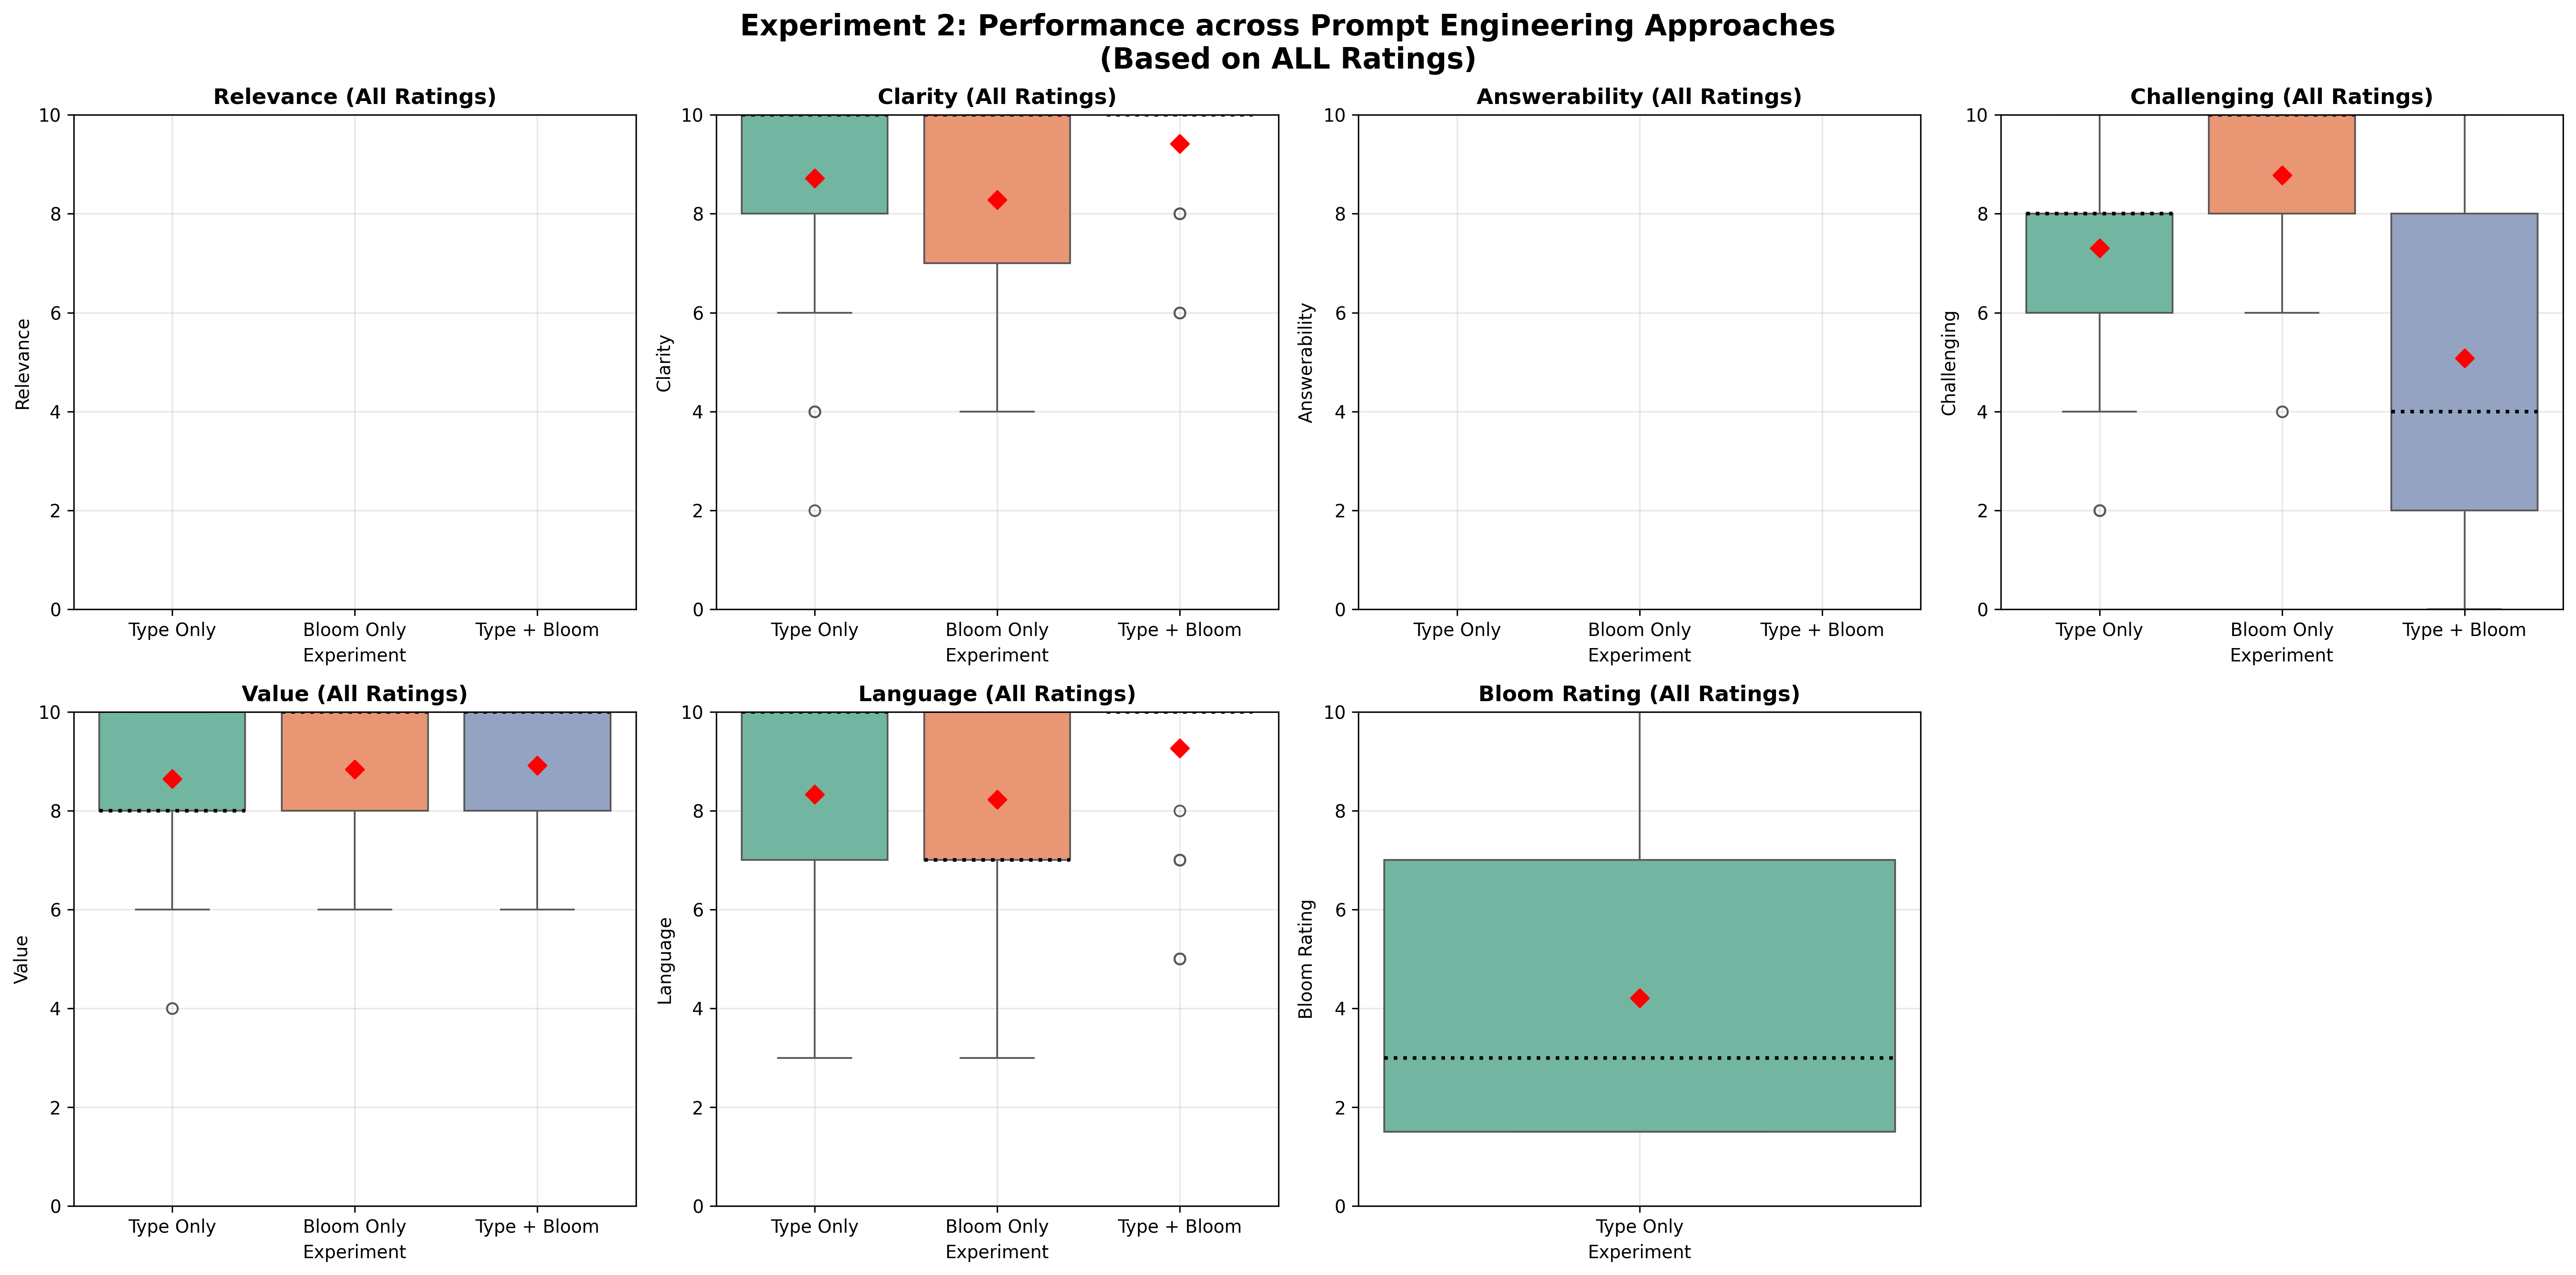

Visualization complete.
Note: This visualization includes all 195 ratings.


In [7]:
# --- DESCRIPTIVE STATISTICS & PLOTS: ALL RATINGS (NO OVERLAP FILTERING) ---

print("EXPERIMENT 2 - DESCRIPTIVE STATISTICS (ALL RATINGS)")

print("="*70)


# No duplicate removal! All ratings are included as-is.
print(f"Number of ratings in df_combined: {len(df_combined)}")


# Create consistent numeric dataset for all ratings
df_numeric = df_combined.copy()


print("Converting metrics to numeric (all ratings)...")
for metric in metrics:
    if metric == 'bloom_rating':
        # For exp2b/exp2c, fetch the correct given Bloom level from the hint data using llm and sample_id
        def bloom_apply(row):
            if row['experiment'] in ['exp2b', 'exp2c']:
                # Find the correct hint row for this sample
                exp = row['experiment']
                llm = row['llm'] if 'llm' in row else None
                sample_id = str(row['sample_id']) if 'sample_id' in row else None
                given_level = None
                if exp in hint_data and llm is not None and sample_id is not None:
                    hint_df = hint_data[exp]
                    # Try to match both llm and sample_id (as string)
                    match = hint_df[(hint_df['llm'] == llm) & (hint_df['sample_id'] == sample_id)]
                    if not match.empty and 'bloom_original' in match.columns:
                        given_level = match.iloc[0]['bloom_original']
                return convert_bloom_rating_simple(row[metric], row['experiment'], given_level)
            else:
                return convert_bloom_rating_simple(row[metric], row['experiment'])
        df_numeric[metric] = df_combined.apply(bloom_apply, axis=1)
    else:
        df_numeric[metric] = pd.to_numeric(df_combined[metric], errors='coerce')


# Basic statistics - ALL ratings
if len(df_numeric) > 0:
    print("\nOverall Statistics (ALL RATINGS, all metrics on 0-10 scale):")
    overall_stats = df_numeric[metrics].describe().round(2)
    display(overall_stats)


    print("\nStatistics by Experiment (ALL RATINGS):")
    exp_stats = df_numeric.groupby('experiment')[metrics].agg(['mean', 'std', 'count']).round(2)
    display(exp_stats)
    
    print(f"\nQuestions per Experiment:")
    for exp in ["exp2a", "exp2b", "exp2c"]:
        exp_data = df_numeric[df_numeric['experiment'] == exp]
        if len(exp_data) > 0:
            questions = sorted(exp_data['question_num'].unique())
            print(f"  {exp}: Questions {questions} ({len(exp_data)} ratings)")
        else:
            print(f"  {exp}: No questions")
else:
    print("\nNo ratings available for statistics.")
    overall_stats = pd.DataFrame()
    exp_stats = pd.DataFrame()


# --- PLOTS: ALL RATINGS ---
print("\n=== VISUALIZATION: PERFORMANCE BY EXPERIMENT (ALL RATINGS) ===")


if len(df_numeric) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()


    for i, metric in enumerate(metrics):
        df_plot = df_numeric[[metric, 'experiment']].dropna()
        if len(df_plot) > 0:
            metric_display = metric_labels[metric]
            colors = ['#66c2a5', '#fc8d62', '#8da0cb']
            sns.boxplot(data=df_plot, x='experiment', y=metric, ax=axes[i], palette=colors,
                        medianprops={'color': 'black', 'linewidth': 2, 'linestyle': ':'})
            # Add mean markers
            for j, exp in enumerate(['exp2a', 'exp2b', 'exp2c']):
                exp_data = df_plot[df_plot['experiment'] == exp][metric]
                if len(exp_data) > 0:
                    mean_val = exp_data.mean()
                    axes[i].scatter(j, mean_val, color='red', marker='D', s=50, zorder=3)
            axes[i].set_ylim(0, 10)
            axes[i].set_title(f'{metric_display} (All Ratings)', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Experiment')
            axes[i].set_ylabel(metric_display)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_xticklabels(['Type Only', 'Bloom Only', 'Type + Bloom'])
        else:
            axes[i].set_title(f'{metric_labels[metric]} - No Data')
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[i].transAxes)
    axes[7].set_visible(False)
    plt.suptitle('Experiment 2: Performance across Prompt Engineering Approaches\n(Based on ALL Ratings)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("Visualization complete.")
    print(f"Note: This visualization includes all {len(df_numeric)} ratings.")
else:
    print("No data available for visualization.")

In [8]:
def convert_bloom_rating_simple(value, experiment, given_level=None):
    """
    Converts bloom_rating to a numeric score based on experiment type.
    For exp2a: uses Bloom level mapping. Handles values like '(4;5;6)' by taking the max.
    For exp2b/exp2c: compares rater's level(s) to the given level (from hints).
        - If any rater level matches given level: 10
        - If any rater level is off by one: 5
        - Else: 0
    """
    bloom_map = {
        'Creating': 10,
        'Evaluating': 8.5,
        'Analyzing': 7,
        'Applying': 4.5,
        'Understanding': 3,
        'Remembering': 1.5,
        6: 10,
        5: 8.5,
        4: 7,
        3: 4.5,
        2: 3,
        1: 1.5
    }
    import re
    # Helper: extract all integer levels from a value (string or int)
    def extract_levels(val):
        if isinstance(val, str):
            nums = re.findall(r'\d+', val)
            return [int(n) for n in nums] if nums else []
        elif isinstance(val, (int, float)) and not pd.isnull(val):
            return [int(val)]
        return []

    if experiment == 'exp2a':
        # Map rater's level(s) to score, use max if multiple
        levels = extract_levels(value)
        if levels:
            max_level = max(levels)
            return bloom_map.get(max_level, np.nan)
        # Try mapping string label if present
        if isinstance(value, str):
            value_clean = value.strip().capitalize()
            return bloom_map.get(value_clean, np.nan)
        return bloom_map.get(value, np.nan)
    elif experiment in ['exp2b', 'exp2c']:
        # Compare rater's level(s) to given_level (from hints)
        rater_levels = extract_levels(value)
        given_levels = extract_levels(given_level) if given_level is not None else []
        if not rater_levels or not given_levels:
            return np.nan
        # For each rater level, compare to each given level, take best possible score
        best_score = 0
        for r in rater_levels:
            for g in given_levels:
                if r == g:
                    best_score = max(best_score, 10)
                elif abs(r - g) == 1:
                    best_score = max(best_score, 5)
        return best_score
    else:
        return np.nan

# Inter-Student Reliability Analysis

Analysis of agreement between student evaluators on overlapping questions.

In [ ]:
# --- FLEISS' KAPPA: ALL QUESTIONS WITH AT LEAST 2 RATINGS ---
print("\n" + "="*60)
print("FLEISS' KAPPA INTER-RATER RELIABILITY ANALYSIS")
print("(ALL QUESTIONS WITH AT LEAST 2 RATINGS)")
print("="*60)

from statsmodels.stats.inter_rater import fleiss_kappa

def kappa_level(k):
    """Interpret Fleiss' Kappa value according to Landis & Koch (1977)"""
    if k < 0.2:
        return "Slight"
    elif k < 0.4:
        return "Fair" 
    elif k < 0.6:
        return "Moderate"
    elif k < 0.8:
        return "Substantial"
    else:
        return "Almost Perfect"

# Find questions with at least 2 ratings
question_counts = df_numeric.groupby('sample_id')['student'].nunique()
multi_rated_questions = question_counts[question_counts >= 2].index.tolist()
print(f"Found {len(multi_rated_questions)} questions with at least 2 ratings.")

# Filter for Kappa: only these questions
kappa_data = df_numeric[df_numeric['sample_id'].isin(multi_rated_questions)].copy()

def calculate_fleiss_kappa_all(metric):
    ratings_data = []
    for q_id in multi_rated_questions:
        q_data = kappa_data[kappa_data['sample_id'] == q_id]
        scores = q_data[metric].dropna()
        if len(scores) >= 2:
            valid_scores = [max(1, min(10, int(round(s)))) for s in scores if 0 <= s <= 10]
            while len(valid_scores) < 3:
                valid_scores.append(np.nan)
            ratings_data.append(valid_scores[:3])
    if len(ratings_data) < 2:
        return np.nan, len(ratings_data)
    ratings_matrix = np.array(ratings_data)
    valid_rows = ~np.isnan(ratings_matrix).all(axis=1)
    clean_ratings = ratings_matrix[valid_rows]
    if len(clean_ratings) == 0:
        return np.nan, 0
    fleiss_table = np.zeros((len(clean_ratings), 10))
    for i, row in enumerate(clean_ratings):
        for r in row:
            if not np.isnan(r) and 1 <= r <= 10:
                fleiss_table[i, int(r)-1] += 1
    try:
        kappa = fleiss_kappa(fleiss_table)
        return kappa, len(clean_ratings)
    except Exception as e:
        print(f"Error calculating Kappa for {metric}: {e}")
        return np.nan, len(clean_ratings)

# Calculate Fleiss' Kappa for all metrics
if len(multi_rated_questions) > 0:
    print(f"\nCalculating Fleiss' Kappa for {len(multi_rated_questions)} questions...")
    print(f"Using {len(kappa_data)} ratings from questions with at least 2 ratings.")
    kappa_results = []
    for metric in metrics:
        metric_display = metric_labels.get(metric, metric)
        kappa, n_questions = calculate_fleiss_kappa_all(metric)
        kappa_results.append({
            'Metric': metric_display,
            'Fleiss_Kappa': kappa,
            'Agreement_Level': kappa_level(kappa) if not np.isnan(kappa) else 'No data',
            'N_Questions': n_questions
        })
    kappa_df = pd.DataFrame(kappa_results)
    print("\nFleiss' Kappa Results (all questions with >=2 ratings):")
    display(kappa_df.round(4))
    valid_kappas = kappa_df.dropna(subset=['Fleiss_Kappa'])
    if len(valid_kappas) > 0:
        avg_kappa = valid_kappas['Fleiss_Kappa'].mean()
        print(f"\nSummary:")
        print(f"Average Fleiss' Kappa: {avg_kappa:.4f} ({kappa_level(avg_kappa)})")
        print(f"Metrics with valid Kappa: {len(valid_kappas)}/{len(kappa_df)}")
    print("\nInterpretation (Landis & Koch, 1977):")
    print("  < 0.20: Slight agreement")
    print("  0.20-0.40: Fair agreement")
    print("  0.40-0.60: Moderate agreement") 
    print("  0.60-0.80: Substantial agreement")
    print("  > 0.80: Almost perfect agreement")
else:
    print("No questions with at least 2 ratings found - Fleiss' Kappa not possible.")
    kappa_df = pd.DataFrame()

SyntaxError: '{' was never closed (406553142.py, line 67)

In [ ]:
def save_results():
    """Save key results from the analysis (ALL RATINGS)."""
    
    print("Saving key results (based on all ratings)...")
    
    # Save basic statistics (all ratings)
    if 'overall_stats' in locals() and not overall_stats.empty:
        overall_stats.to_csv(os.path.join(output_tables_path, "exp2_overall_statistics_all.csv"))
        print("Saved overall statistics (all ratings)")
    
    if 'exp_stats' in locals() and not exp_stats.empty:
        exp_stats.to_csv(os.path.join(output_tables_path, "exp2_experiment_statistics_all.csv"))
        print("Saved experiment statistics (all ratings)")
    
    # Save Fleiss' Kappa results
    if 'kappa_df' in locals() and not kappa_df.empty:
        kappa_df.to_csv(os.path.join(output_tables_path, "exp2_fleiss_kappa_all.csv"), index=False)
        print("Saved Fleiss' Kappa results (all ratings)")
    
    print(f"\nResults saved to: {output_tables_path}")

# Execute save
save_results()

print(f"\n" + "="*60)
print("ANALYSIS COMPLETE - ALL RATINGS")
print("="*60)
print(f"Data loaded: {len(df_combined)} total evaluations")
print(f"Metrics analyzed: {len(metrics)}")
print(f"Students: {sorted(df_combined['student'].unique())}")
print(f"Experiments: {sorted(df_combined['experiment'].unique())}")

Saving key results (based on all ratings)...

Results saved to: /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/tables

ANALYSIS COMPLETE - ALL RATINGS
Data loaded: 195 total evaluations
Metrics analyzed: 7
Students: [np.int64(1), np.int64(2), np.int64(3)]
Experiments: ['exp2a', 'exp2b', 'exp2c']
